In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import sys
sys.path.append('..')
from config import *

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve,
                              average_precision_score,
                              f1_score, precision_score,
                              recall_score)
from sklearn.model_selection import (StratifiedKFold,
                                      cross_val_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded!")

Libraries loaded!


In [4]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print("Data loaded successfully!")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.value_counts().to_dict()}")
print(f"y_test  : {y_test.value_counts().to_dict()}")

Data loaded successfully!
X_train : (81410, 35)
X_test  : (20353, 35)
y_train : {0: 72324, 1: 9086}
y_test  : {0: 18082, 1: 2271}


In [5]:
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print(f"Scaler saved → {MODELS_DIR / 'scaler.pkl'}")

Scaler saved → d:\Projects\healthcare-readmission-predictor\notebooks\..\models\scaler.pkl


In [6]:
print("Applying SMOTE to handle class imbalance...")
smote = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote.fit_resample(X_train_sc, y_train)

print(f"Before SMOTE: {dict(pd.Series(y_train).value_counts())}")
print(f"After SMOTE : {dict(pd.Series(y_res).value_counts())}")
print(f"New shape   : {X_res.shape}")

Applying SMOTE to handle class imbalance...
Before SMOTE: {0: np.int64(72324), 1: np.int64(9086)}
After SMOTE : {0: np.int64(72324), 1: np.int64(72324)}
New shape   : (144648, 35)


In [7]:
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_STATE, max_iter=1000, C=0.1),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=RANDOM_STATE, n_jobs=-1),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5,
        learning_rate=0.05, random_state=RANDOM_STATE),

    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6,
        learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0),

    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6,
        learning_rate=0.05, random_state=RANDOM_STATE,
        verbose=-1, n_jobs=-1)
}

results = {}

print(f"{'Model':<22} {'ROC-AUC':>9} {'F1':>8} "
      f"{'Precision':>11} {'Recall':>8}")
print("-" * 62)

for name, model in models.items():
    model.fit(X_res, y_res)
    y_pred      = model.predict(X_test_sc)
    y_prob      = model.predict_proba(X_test_sc)[:, 1]

    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)

    results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'y_prob' : y_prob,
        'auc'    : auc,
        'f1'     : f1,
        'precision': prec,
        'recall' : rec
    }

    print(f"{name:<22} {auc:>9.4f} {f1:>8.4f} "
          f"{prec:>11.4f} {rec:>8.4f}")

best_name = max(results, key=lambda x: results[x]['auc'])
print(f"\nBest model: {best_name}")

Model                    ROC-AUC       F1   Precision   Recall
--------------------------------------------------------------
Logistic Regression       0.6421   0.2542      0.1659   0.5443
Random Forest             0.6380   0.1887      0.2142   0.1686
Gradient Boosting         0.6641   0.0382      0.5114   0.0198
XGBoost                   0.6694   0.0350      0.5694   0.0181
LightGBM                  0.6733   0.0224      0.5098   0.0114

Best model: LightGBM


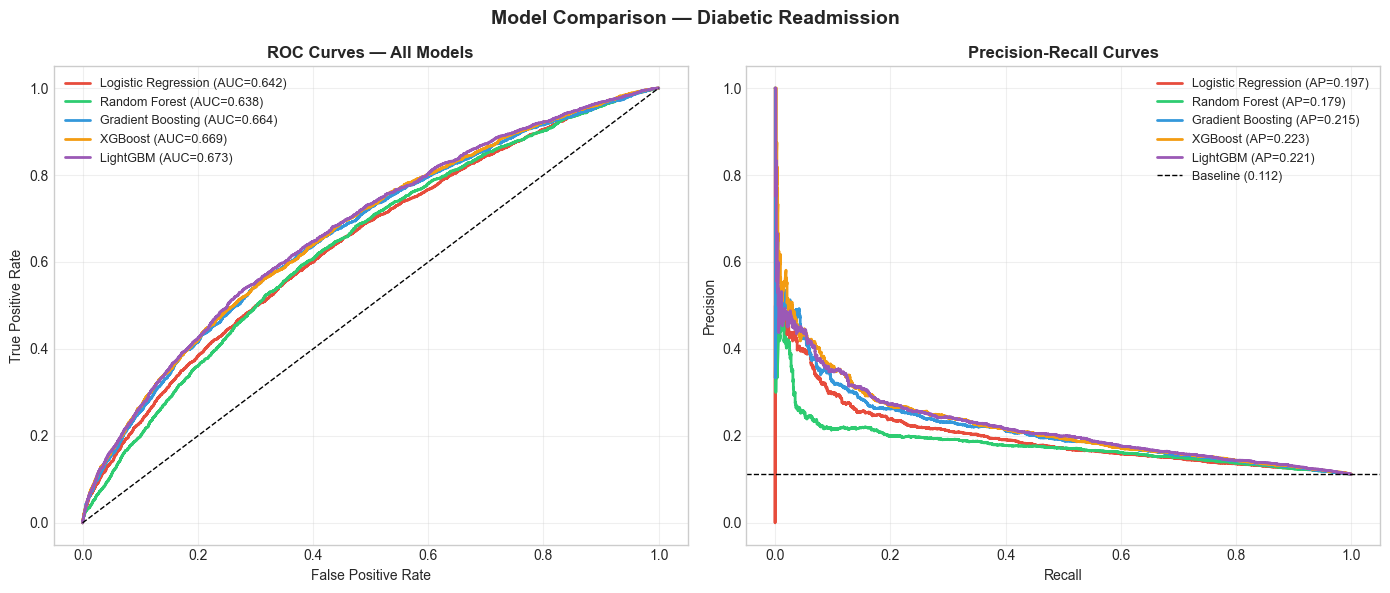

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#E74C3C', '#2ECC71', '#3498DB',
          '#F39C12', '#9B59B6']

for (name, res), color in zip(results.items(), colors):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} (AUC={res['auc']:.3f})")

    # PR
    prec_c, rec_c, _ = precision_recall_curve(
        y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    axes[1].plot(rec_c, prec_c, color=color, linewidth=2,
                 label=f"{name} (AP={ap:.3f})")

# ROC
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# PR
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k',
                linestyle='--', linewidth=1,
                label=f'Baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison — Diabetic Readmission',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_pr_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

Clinical Metrics — LightGBM
Sensitivity (Recall) : 1.14%
Specificity          : 99.86%
PPV (Precision)      : 50.98%
NPV                  : 88.94%
ROC-AUC              : 67.33%


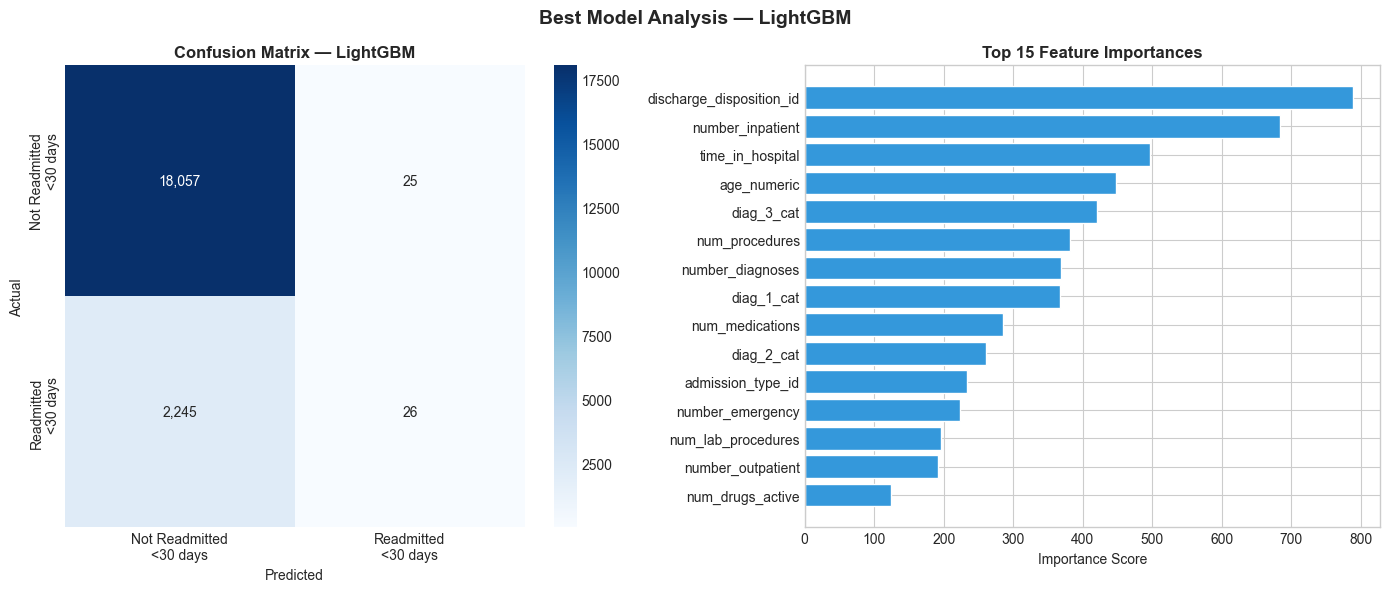

In [9]:
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
cm   = confusion_matrix(y_test, best['y_pred'])
disp_labels = ['Not Readmitted\n<30 days',
               'Readmitted\n<30 days']
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=disp_labels,
            yticklabels=disp_labels, ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_name}',
                   fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Clinical metrics from CM
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp)
npv         = tn / (tn + fn)

print(f"Clinical Metrics — {best_name}")
print("=" * 42)
print(f"Sensitivity (Recall) : {sensitivity*100:.2f}%")
print(f"Specificity          : {specificity*100:.2f}%")
print(f"PPV (Precision)      : {ppv*100:.2f}%")
print(f"NPV                  : {npv*100:.2f}%")
print(f"ROC-AUC              : {best['auc']*100:.2f}%")

# Feature importance
best_model = best['model']
if hasattr(best_model, 'feature_importances_'):
    importance  = best_model.feature_importances_
    feat_df     = pd.DataFrame({
        'feature'   : X_train.columns,
        'importance': importance
    }).sort_values('importance', ascending=False).head(15)

    axes[1].barh(feat_df['feature'][::-1],
                 feat_df['importance'][::-1],
                 color='#3498DB', edgecolor='white')
    axes[1].set_title('Top 15 Feature Importances',
                       fontweight='bold')
    axes[1].set_xlabel('Importance Score')

plt.suptitle(f'Best Model Analysis — {best_name}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'best_model_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

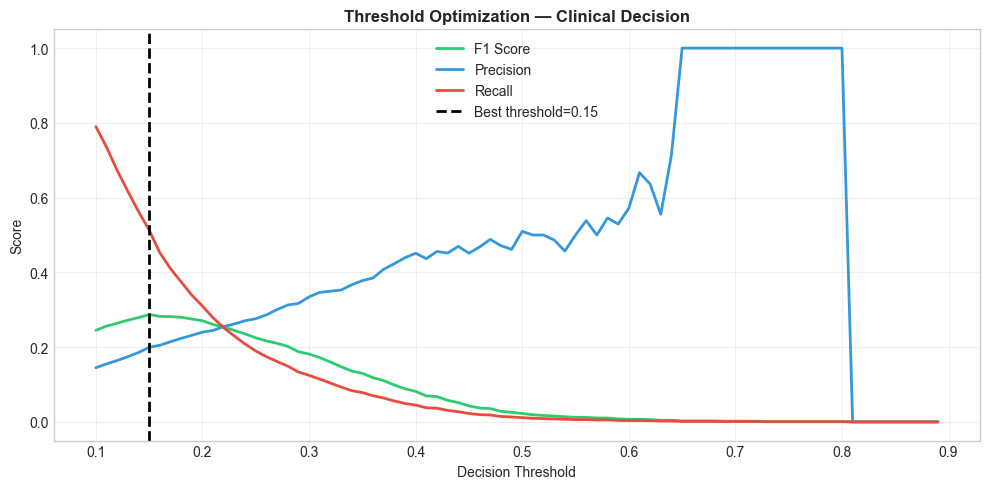

Optimal threshold : 0.15
F1 at threshold   : 0.2873

Final Classification Report:
               precision    recall  f1-score   support

    Not Early       0.92      0.74      0.82     18082
Early Readmit       0.20      0.51      0.29      2271

     accuracy                           0.72     20353
    macro avg       0.56      0.63      0.55     20353
 weighted avg       0.84      0.72      0.76     20353



In [10]:
# Clinical context: missing a high-risk patient is costly
# Optimize threshold for best F1 on minority class

thresholds  = np.arange(0.1, 0.9, 0.01)
f1_scores   = []
prec_scores = []
rec_scores  = []

for thresh in thresholds:
    y_pred_t = (best['y_prob'] >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t,
                               zero_division=0))
    prec_scores.append(precision_score(y_test, y_pred_t,
                                        zero_division=0))
    rec_scores.append(recall_score(y_test, y_pred_t,
                                    zero_division=0))

best_thresh_idx = np.argmax(f1_scores)
best_thresh     = thresholds[best_thresh_idx]
best_f1_thresh  = f1_scores[best_thresh_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores,   color='#2ECC71',
         linewidth=2, label='F1 Score')
plt.plot(thresholds, prec_scores, color='#3498DB',
         linewidth=2, label='Precision')
plt.plot(thresholds, rec_scores,  color='#E74C3C',
         linewidth=2, label='Recall')
plt.axvline(x=best_thresh, color='black',
            linestyle='--', linewidth=2,
            label=f'Best threshold={best_thresh:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization — Clinical Decision',
          fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'threshold_optimization.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal threshold : {best_thresh:.2f}")
print(f"F1 at threshold   : {best_f1_thresh:.4f}")

# Final predictions with optimal threshold
y_final = (best['y_prob'] >= best_thresh).astype(int)
print(f"\nFinal Classification Report:")
print(classification_report(y_test, y_final,
      target_names=['Not Early', 'Early Readmit']))

In [11]:
best_model_obj = results[best_name]['model']

joblib.dump(best_model_obj,
            MODELS_DIR / 'readmission_model.pkl')
joblib.dump({'threshold'  : float(best_thresh),
             'model_name' : best_name,
             'features'   : X_train.columns.tolist(),
             'auc'        : float(best['auc'])},
            MODELS_DIR / 'model_metadata.pkl')

print(f"Model saved      → {MODELS_DIR / 'readmission_model.pkl'}")
print(f"Metadata saved   → {MODELS_DIR / 'model_metadata.pkl'}")

Model saved      → d:\Projects\healthcare-readmission-predictor\notebooks\..\models\readmission_model.pkl
Metadata saved   → d:\Projects\healthcare-readmission-predictor\notebooks\..\models\model_metadata.pkl


In [12]:
print("=" * 58)
print("DIABETIC PATIENT READMISSION — MODELING REPORT")
print("=" * 58)
print(f"Dataset          : 101,763 patient encounters")
print(f"Task             : Early readmission (<30 days)")
print(f"Class imbalance  : 1:7 → handled with SMOTE")
print(f"Features         : {X_train.shape[1]}")
print()
print(f"{'Model':<22} {'AUC':>8} {'F1':>8} {'Recall':>8}")
print("-" * 50)
for name, res in sorted(results.items(),
                          key=lambda x: x[1]['auc'],
                          reverse=True):
    marker = ' ← BEST' if name == best_name else ''
    print(f"{name:<22} {res['auc']:>8.4f} "
          f"{res['f1']:>8.4f} {res['recall']:>8.4f}{marker}")
print()
print(f"Best model       : {best_name}")
print(f"AUC-ROC          : {best['auc']*100:.2f}%")
print(f"Optimal threshold: {best_thresh:.2f}")
print(f"F1 (optimized)   : {best_f1_thresh*100:.2f}%")
print()
print("Clinical Impact:")
print(f"  True Positives  : {tp:,} high-risk patients caught")
print(f"  False Negatives : {fn:,} missed high-risk patients")
print(f"  Sensitivity     : {sensitivity*100:.1f}%")
print(f"  Specificity     : {specificity*100:.1f}%")
print()
print("Next Step: api/main.py + app/streamlit_app.py")
print("=" * 58)

DIABETIC PATIENT READMISSION — MODELING REPORT
Dataset          : 101,763 patient encounters
Task             : Early readmission (<30 days)
Class imbalance  : 1:7 → handled with SMOTE
Features         : 35

Model                       AUC       F1   Recall
--------------------------------------------------
LightGBM                 0.6733   0.0224   0.0114 ← BEST
XGBoost                  0.6694   0.0350   0.0181
Gradient Boosting        0.6641   0.0382   0.0198
Logistic Regression      0.6421   0.2542   0.5443
Random Forest            0.6380   0.1887   0.1686

Best model       : LightGBM
AUC-ROC          : 67.33%
Optimal threshold: 0.15
F1 (optimized)   : 28.73%

Clinical Impact:
  True Positives  : 26 high-risk patients caught
  False Negatives : 2,245 missed high-risk patients
  Sensitivity     : 1.1%
  Specificity     : 99.9%

Next Step: api/main.py + app/streamlit_app.py


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Clinical priority: Recall > Precision
# Missing a high-risk patient = worse than false alarm

# Logistic Regression with class weight
lr_clinical = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    C=0.1,
    class_weight={0: 1, 1: 7}  # reflect true imbalance
)
lr_clinical.fit(X_res, y_res)

y_prob_lr = lr_clinical.predict_proba(X_test_sc)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)

# Find threshold optimizing recall >= 60%
thresholds = np.arange(0.05, 0.95, 0.01)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    y_t  = (y_prob_lr >= t).astype(int)
    rec  = recall_score(y_test, y_t, zero_division=0)
    prec = precision_score(y_test, y_t, zero_division=0)
    f1   = f1_score(y_test, y_t, zero_division=0)
    # Clinical threshold: recall >= 50%
    if rec >= 0.50 and f1 > best_f1:
        best_f1 = f1
        best_t  = t

y_final_lr = (y_prob_lr >= best_t).astype(int)

print("CLINICALLY OPTIMIZED MODEL")
print("=" * 50)
print(f"Model            : Logistic Regression")
print(f"Class weight     : 1:7 (reflects imbalance)")
print(f"AUC-ROC          : {auc_lr:.4f}")
print(f"Optimal threshold: {best_t:.2f}")
print()
print(classification_report(
    y_test, y_final_lr,
    target_names=['Not Early Readmit', 'Early Readmit']))

# Save this as final model
joblib.dump(lr_clinical,
            MODELS_DIR / 'readmission_model.pkl')
joblib.dump({
    'threshold'  : float(best_t),
    'model_name' : 'Logistic Regression (clinical)',
    'features'   : X_train.columns.tolist(),
    'auc'        : float(auc_lr)},
    MODELS_DIR / 'model_metadata.pkl')

print(f"\nFinal model saved!")

CLINICALLY OPTIMIZED MODEL
Model            : Logistic Regression
Class weight     : 1:7 (reflects imbalance)
AUC-ROC          : 0.6426
Optimal threshold: 0.88

                   precision    recall  f1-score   support

Not Early Readmit       0.92      0.69      0.79     18082
    Early Readmit       0.17      0.51      0.25      2271

         accuracy                           0.67     20353
        macro avg       0.54      0.60      0.52     20353
     weighted avg       0.83      0.67      0.73     20353


Final model saved!
